In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



In [2]:
# Parámetro k
k = 3

# Cargar dataset iris
iris = pd.read_csv('iris.csv')

# Separar características y etiquetas
X = iris.iloc[:, :-1].values
y = iris.iloc[:, -1].values
features = iris.columns[:-1]



In [3]:
# Función para calcular distancias euclidianas
def calcular_distancias(punto, conjunto_puntos):
    return np.linalg.norm(conjunto_puntos - punto, axis=1)

# Dividir en 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)




Tiempo total de ejecución: 0.0165 segundos

Precisión del clasificador k-NN (k=3) sobre el conjunto de prueba: 100.00%


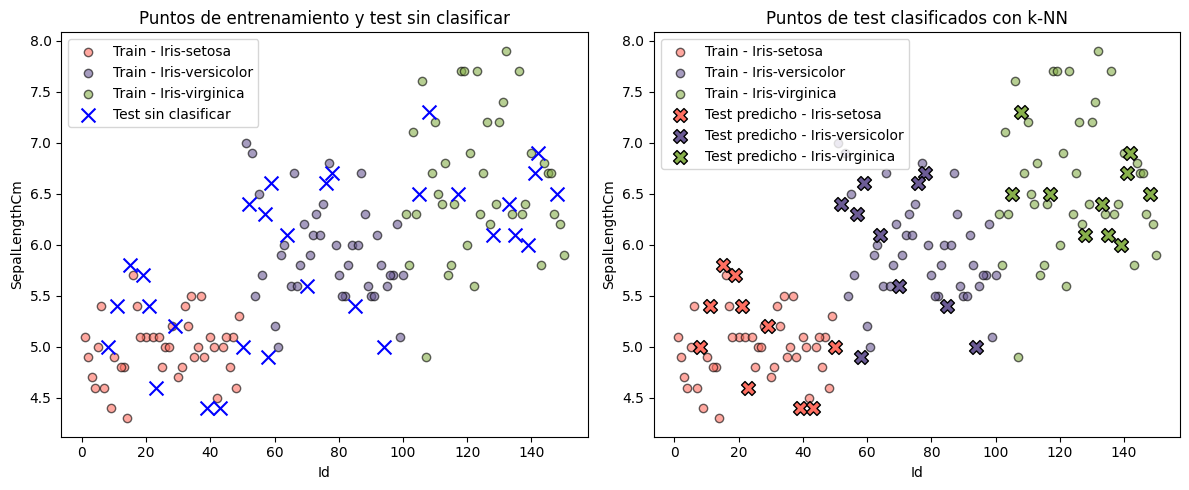

In [4]:
import time

# Graficar los Puntos de test antes de clasificar
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colores = {
    'Iris-setosa': '#FF6F61',       # Coral
    'Iris-versicolor': '#6B5B95',   # Púrpura
    'Iris-virginica': '#88B04B'     # Verde oliva
}

# Entrenamiento coloreado
for especie in np.unique(y_train):
    idx = y_train == especie
    plt.scatter(X_train[idx, 0], X_train[idx, 1], label=f'Train - {especie}',
                alpha=0.6, edgecolors='k', color=colores[especie])

# Test sin clasificar
plt.scatter(X_test[:, 0], X_test[:, 1], label='Test sin clasificar',
            color='blue', marker='x', s=100)

plt.title('Puntos de entrenamiento y test sin clasificar')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend()

# Graficar los Puntos de test clasificados

# Clasificar puntos de test usando k-NN manual
inicio = time.time()
predicciones = []

for punto_test in X_test:
    distancias = calcular_distancias(punto_test, X_train)
    indices_vecinos = distancias.argsort()[:k]
    vecinos = y_train[indices_vecinos]
    predicha = pd.Series(vecinos).value_counts().idxmax()
    predicciones.append(predicha)

fin = time.time()
print(f"\nTiempo total de ejecución: {fin - inicio:.4f} segundos")

# Calcular precisión
precision = accuracy_score(y_test, predicciones)
print(f"\nPrecisión del clasificador k-NN (k={k}) sobre el conjunto de prueba: {precision:.2%}")

plt.subplot(1, 2, 2)

# Entrenamiento
for especie in np.unique(y_train):
    idx = y_train == especie
    plt.scatter(X_train[idx, 0], X_train[idx, 1], label=f'Train - {especie}',
                alpha=0.6, edgecolors='k', color=colores[especie])

# Test clasificados por predicción
for especie in np.unique(predicciones):
    idx = np.array(predicciones) == especie
    plt.scatter(X_test[idx, 0], X_test[idx, 1],
                label=f'Test predicho - {especie}',
                marker='X', s=100, edgecolors='k', color=colores[especie])

plt.title(f'Puntos de test clasificados con k-NN')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend()

plt.tight_layout()
plt.show()
